In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("Task3.csv")

In [3]:
print("Shape:", df.shape)
df.info()
print("\nMissing values:\n", df.isnull().sum())
df.describe()

Shape: (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad 

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


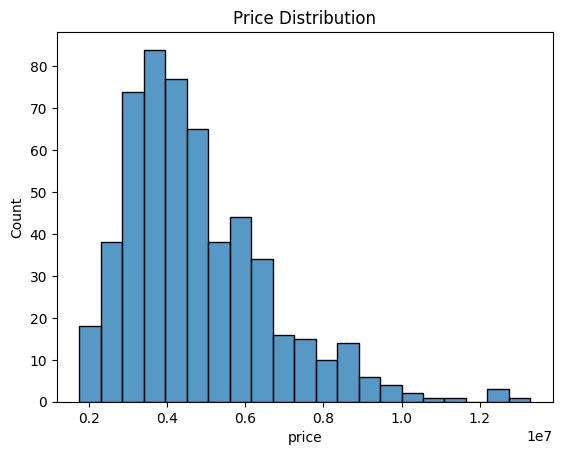

In [4]:
sns.histplot(df['price'])   # shows how many houses fall in each price range
plt.title("Price Distribution")
plt.show()

**Insight:** House prices are right-skewed — most properties fall between roughly 2M and 6M, with a smaller number of high-priced outliers stretching the distribution up to ~13M.

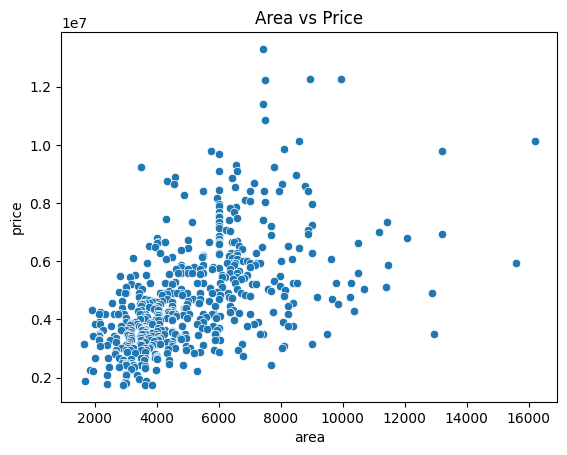

In [5]:
sns.scatterplot(x=df['area'], y=df['price'])   # each dot = one house
plt.title("Area vs Price")
plt.show()

**Insight:** There is a clear positive relationship between area and price — larger properties tend to sell for more, though the relationship isn't perfectly linear, since some large properties are priced similarly to smaller ones.

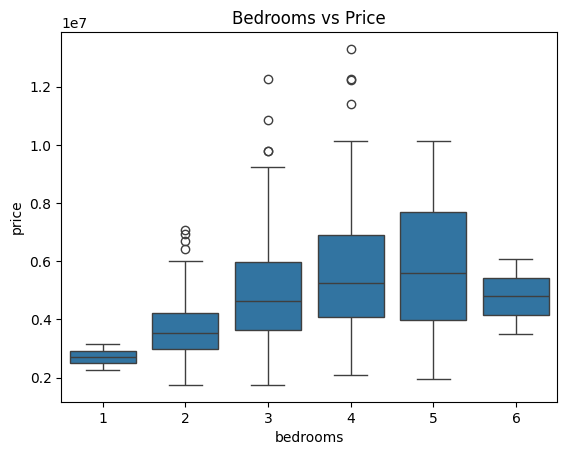

In [6]:
sns.boxplot(x=df['bedrooms'], y=df['price'])   # compares price across bedroom counts
plt.title("Bedrooms vs Price")
plt.show()

**Insight:** Median price rises from 1 to 5 bedrooms, but interestingly drops slightly for 6-bedroom homes — suggesting bedroom count alone doesn't fully explain price beyond a certain point.

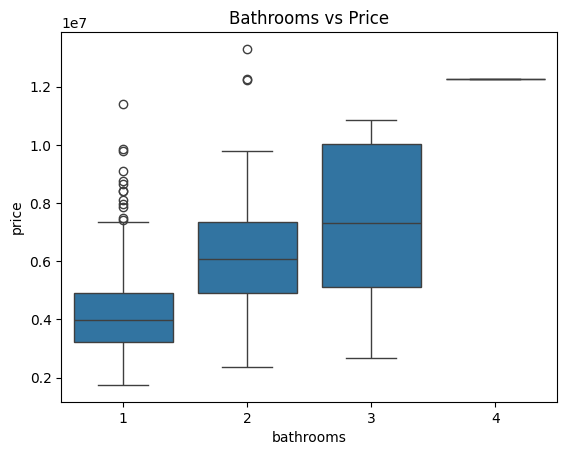

In [7]:
sns.boxplot(x=df['bathrooms'], y=df['price'])
plt.title("Bathrooms vs Price")
plt.show()

**Insight:** Bathrooms show a strong, consistent positive relationship with price — each additional bathroom tends to push the median price notably higher, more consistently than bedrooms do.

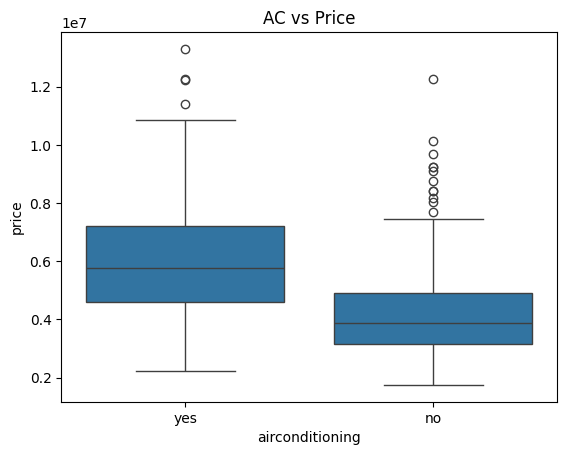

In [8]:
sns.boxplot(x=df['airconditioning'], y=df['price'])
plt.title("AC vs Price")
plt.show()

**Insight:** Homes with air conditioning have a visibly higher median price than those without, making AC one of the stronger categorical price indicators in this dataset.

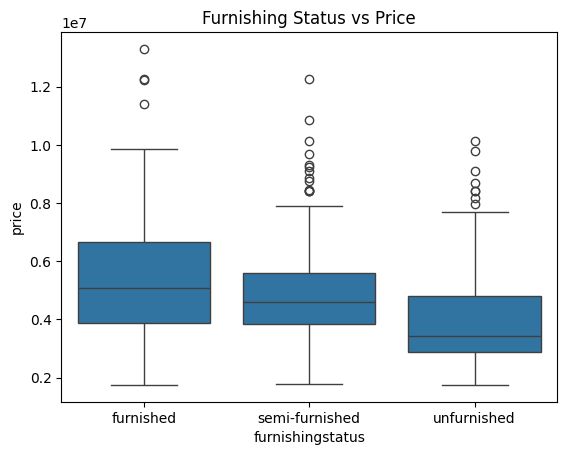

In [9]:
sns.boxplot(x=df['furnishingstatus'], y=df['price'])
plt.title("Furnishing Status vs Price")
plt.show()

**Insight:** Furnished homes have the highest median price, followed by semi-furnished, then unfurnished — furnishing status has a smaller but still visible effect on price.

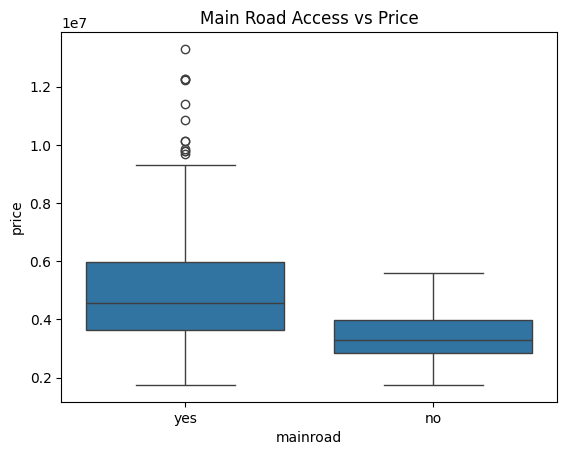

In [10]:
sns.boxplot(x=df['mainroad'], y=df['price'])
plt.title("Main Road Access vs Price")
plt.show()

**Insight:** Homes with main road access have a higher median price than those without, likely reflecting the added convenience and accessibility buyers value.

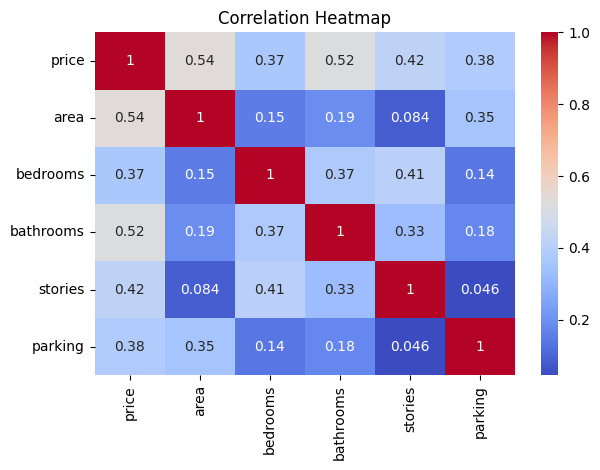

In [11]:
numeric_df = df.select_dtypes(include='number')   # keep only number columns
corr = numeric_df.corr()                          # calculate correlation between all of them

sns.heatmap(corr, annot=True, cmap='coolwarm')     # annot=True shows the numbers on the chart
plt.title("Correlation Heatmap")
plt.tight_layout()                                 # fixes squished/overlapping axis labels
plt.show()

**Insight:** Area (0.54) and bathrooms (0.52) have the strongest positive correlation with price, followed by stories (0.42), parking (0.38), and bedrooms (0.37) — confirming that size and bathroom count matter more to price than raw bedroom count.

## Conclusion

This EDA shows that price is primarily driven by property size (area) and bathroom count, with air conditioning, main road access, and furnishing status also contributing meaningful premiums. Price itself is right-skewed, meaning a small number of high-end properties pull the average above what a "typical" home costs — the median is a more representative figure. Bedroom count matters less than expected, plateauing (and even dipping) beyond 5 bedrooms, suggesting buyers value usable space and amenities over sheer room count.
